# Clase 2 — Políticas, Funciones de Valor, Ecuación de Bellman y Bandidos

**Curso:** Aprendizaje por Refuerzo: Fundamentos y Aplicaciones
**Institución:** Universidad Austral — Facultad de Ingeniería (Posgrados)
**Docente:** Dr. Darío Ezequiel Díaz
**Fecha:** 12 de mayo de 2026

---

## Resumen del cuaderno

Este cuaderno acompaña la segunda clase del curso y aterriza en código los conceptos teóricos discutidos durante la sesión sincrónica. La estructura sigue, por orden, los nueve bloques temáticos anunciados en la diapositiva 40:

1. **Construcción del GridWorld** que sirve de laboratorio durante todo el cuaderno.
2. **Resolución cerrada** de la ecuación de Bellman mediante inversión matricial: $V^\pi = (I - \gamma P^\pi)^{-1} R^\pi$.
3. **Evaluación iterativa** de la política y verificación empírica de la convergencia geométrica del operador $\mathcal{T}^\pi$.
4. **Bandido gaussiano de diez brazos**, replicando el escenario canónico de la figura 2.2 de Sutton y Barto.
5. **Estrategia $\varepsilon$-greedy**, implementada con promedio incremental.
6. **Estrategia UCB1**, basada en el principio de optimismo bajo incertidumbre.
7. **Thompson sampling gaussiano**, la alternativa bayesiana clásica.
8. **Comparación experimental** sobre múltiples réplicas independientes.
9. **Análisis estadístico** del regret con intervalos de confianza y pruebas de hipótesis.

> **Compatibilidad:** Este cuaderno se ejecuta sin modificaciones tanto en un entorno local con Python 3.10+ como en Google Colab. No requiere GPU.

## Bloque 0 — Configuración del entorno

Importamos las bibliotecas necesarias y fijamos parámetros gráficos. El uso de una semilla global garantiza la reproducibilidad de los resultados que aparecerán a continuación.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats

# Reproducibilidad
SEMILLA_GLOBAL = 42
np.random.seed(SEMILLA_GLOBAL)

# Paleta institucional
COLOR_NAVY = '#1E3A5F'
COLOR_ORANGE = '#D86A2C'
COLOR_TEAL = '#2E8A99'
COLOR_LIGHT_TEAL = '#9FD3D8'
COLOR_LIGHT_ORANGE = '#F2A06B'
COLOR_GRAY = '#4A4A4A'

# Estilo de figuras
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.titlecolor': COLOR_NAVY,
    'legend.fontsize': 10,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Configuración cargada correctamente.')

Configuración cargada correctamente.


## Bloque 1 — GridWorld: el laboratorio de la clase

Definimos un entorno determinista de tipo **GridWorld** sobre una cuadrícula $4 \times 4$, con dos celdas inalcanzables (muros) que obligan al agente a rodear el centro del tablero. Esta configuración replica exactamente la utilizada en la diapositiva 15 de la presentación.

**Convenciones del entorno:**

- Estado inicial $S = (3, 0)$ en la esquina inferior izquierda.
- Meta $G = (0, 3)$ en la esquina superior derecha.
- Muros en $(2, 1)$ y $(2, 2)$, en la fila inmediatamente superior a $S$.
- Acciones: arriba, derecha, abajo e izquierda, codificadas como enteros $0, 1, 2, 3$.
- Recompensa de paso: $-0.1$ (penalización por demora).
- Recompensa terminal: $+1$ al alcanzar $G$.
- Si la acción intentaría salir de la grilla o atravesar un muro, el agente permanece en su estado.

In [2]:
class GridWorld:
    """
    GridWorld determinista 4x4 con muros.
    
    Convención de coordenadas: (fila, columna), con fila=0 en la parte superior.
    Acciones: 0=arriba, 1=derecha, 2=abajo, 3=izquierda.
    """
    
    def __init__(self, n_filas=4, n_cols=4, muros=None,
                 inicio=(3, 0), meta=(0, 3),
                 recompensa_paso=-0.1, recompensa_meta=1.0):
        self.n_filas = n_filas
        self.n_cols = n_cols
        self.muros = set(muros) if muros else set()
        self.inicio = inicio
        self.meta = meta
        self.recompensa_paso = recompensa_paso
        self.recompensa_meta = recompensa_meta
        
        # Acciones codificadas como desplazamientos (delta_fila, delta_col)
        self.acciones = [(-1, 0), (0, 1), (1, 0), (0, -1)]
        self.nombres_acciones = ['↑', '→', '↓', '←']
        
        # Estados válidos: todas las celdas excepto muros
        self.estados = [(r, c) for r in range(n_filas)
                        for c in range(n_cols)
                        if (r, c) not in self.muros]
        self.idx_estado = {s: i for i, s in enumerate(self.estados)}
        self.n_estados = len(self.estados)
        self.n_acciones = len(self.acciones)
    
    def transicion(self, estado, accion):
        """
        Aplica una acción y devuelve (estado_siguiente, recompensa, terminal).
        """
        # Estado terminal: absorbente
        if estado == self.meta:
            return estado, 0.0, True
        
        dr, dc = self.acciones[accion]
        nr, nc = estado[0] + dr, estado[1] + dc
        
        # Validación: no salir de la grilla ni atravesar muros
        fuera_grilla = (nr < 0 or nr >= self.n_filas or 
                        nc < 0 or nc >= self.n_cols)
        if fuera_grilla or (nr, nc) in self.muros:
            siguiente = estado
        else:
            siguiente = (nr, nc)
        
        if siguiente == self.meta:
            return siguiente, self.recompensa_meta, True
        return siguiente, self.recompensa_paso, False


# Instanciar el GridWorld con los muros de la presentación
gw = GridWorld(muros={(2, 1), (2, 2)})

print(f'Espacio de estados: {gw.n_estados} estados válidos')
print(f'Espacio de acciones: {gw.n_acciones} acciones')
print(f'Inicio: {gw.inicio}, Meta: {gw.meta}')
print(f'Muros: {sorted(gw.muros)}')

Espacio de estados: 14 estados válidos
Espacio de acciones: 4 acciones
Inicio: (3, 0), Meta: (0, 3)
Muros: [(2, 1), (2, 2)]


### Visualización del entorno

Implementamos una función auxiliar para dibujar el GridWorld. La utilizaremos varias veces a lo largo del cuaderno para mostrar valores de estado, políticas y mapas de calor.

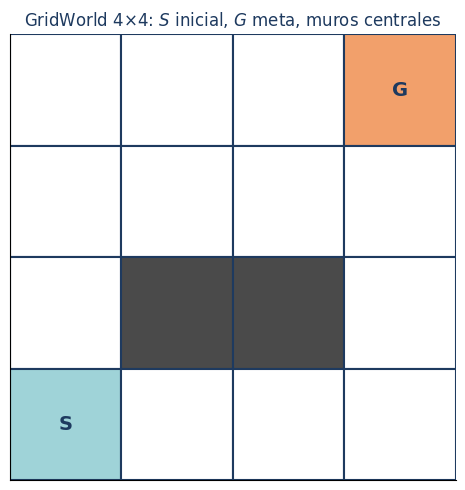

In [3]:
def dibujar_gridworld(env, valores=None, politica=None, ax=None,
                      titulo="GridWorld", mostrar_acciones=False):
    """
    Dibuja la grilla. Si se proporcionan `valores`, los muestra en cada celda.
    Si se proporciona `politica` y `mostrar_acciones=True`, dibuja flechas con
    la acción más probable en cada estado.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    
    for r in range(env.n_filas):
        for c in range(env.n_cols):
            # Y plot invertida: fila 0 arriba
            y_plot = env.n_filas - 1 - r
            color = 'white'
            etiqueta = ''
            
            if (r, c) in env.muros:
                color = COLOR_GRAY
            elif (r, c) == env.inicio:
                color = COLOR_LIGHT_TEAL
                etiqueta = 'S'
            elif (r, c) == env.meta:
                color = COLOR_LIGHT_ORANGE
                etiqueta = 'G'
            
            ax.add_patch(patches.Rectangle(
                (c, y_plot), 1, 1,
                facecolor=color, edgecolor=COLOR_NAVY, linewidth=1.5
            ))
            
            # Mostrar valor numérico
            if (valores is not None and (r, c) not in env.muros
                    and (r, c) != env.inicio and (r, c) != env.meta):
                v = valores[env.idx_estado[(r, c)]]
                ax.text(c + 0.5, y_plot + 0.5, f'{v:.2f}',
                        ha='center', va='center', fontsize=10, color=COLOR_NAVY)
            elif etiqueta:
                ax.text(c + 0.5, y_plot + 0.5, etiqueta,
                        ha='center', va='center',
                        fontsize=14, fontweight='bold', color=COLOR_NAVY)
            
            # Mostrar acción más probable
            if (mostrar_acciones and politica is not None
                    and (r, c) not in env.muros and (r, c) != env.meta):
                a_estrella = np.argmax(politica[env.idx_estado[(r, c)]])
                flecha = env.nombres_acciones[a_estrella]
                ax.text(c + 0.5, y_plot + 0.15, flecha,
                        ha='center', va='center', fontsize=10, color=COLOR_ORANGE)
    
    ax.set_xlim(0, env.n_cols)
    ax.set_ylim(0, env.n_filas)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(titulo)
    return ax


fig, ax = plt.subplots(figsize=(5, 5))
dibujar_gridworld(gw, titulo='GridWorld 4×4: $S$ inicial, $G$ meta, muros centrales', ax=ax)
plt.tight_layout()
plt.show()

## Bloque 2 — Resolución cerrada de la ecuación de Bellman

Recordemos la ecuación de Bellman para evaluación de políticas, expresada en forma matricial (diapositiva 19):

$$
V^\pi = R^\pi + \gamma\, P^\pi V^\pi
\quad\Longleftrightarrow\quad
V^\pi = (I - \gamma P^\pi)^{-1} R^\pi.
$$

La existencia de la inversa queda garantizada porque $\gamma < 1$ y $P^\pi$ es una matriz estocástica, lo cual hace que $\|\gamma P^\pi\|_\infty = \gamma < 1$, y por la serie de Neumann $(I - \gamma P^\pi)^{-1} = \sum_{k=0}^\infty (\gamma P^\pi)^k$ converge absolutamente.

### 2.1. Construcción de la dinámica inducida

Dada una política $\pi$, construimos los objetos $P^\pi \in \mathbb{R}^{n \times n}$ y $R^\pi \in \mathbb{R}^n$ marginalizando sobre las acciones.

In [4]:
def construir_dinamica_inducida(env, politica):
    """
    Construye la matriz de transición inducida P^pi y el vector de
    recompensa inducida R^pi bajo la política `politica`.
    
    Parámetros
    ----------
    env : GridWorld
        Entorno con dinámica determinista.
    politica : np.ndarray, shape (n_estados, n_acciones)
        Distribución sobre acciones para cada estado.
    
    Devuelve
    --------
    P_pi : np.ndarray, shape (n_estados, n_estados)
    R_pi : np.ndarray, shape (n_estados,)
    """
    n = env.n_estados
    P_pi = np.zeros((n, n))
    R_pi = np.zeros(n)
    
    for i, s in enumerate(env.estados):
        for a in range(env.n_acciones):
            s_sig, r, _ = env.transicion(s, a)
            j = env.idx_estado[s_sig]
            P_pi[i, j] += politica[i, a]
            R_pi[i] += politica[i, a] * r
    
    return P_pi, R_pi


# Política equiprobable: pi(a|s) = 1/4 para toda accion a en todo estado s
pol_uniforme = np.ones((gw.n_estados, gw.n_acciones)) / gw.n_acciones

P_pi, R_pi = construir_dinamica_inducida(gw, pol_uniforme)

# Verificación: cada fila de P_pi debe sumar 1 (es estocástica)
print('Verificación: filas de P^pi suman uno?')
suma_filas = P_pi.sum(axis=1)
print(f'  min suma fila = {suma_filas.min():.6f}')
print(f'  max suma fila = {suma_filas.max():.6f}')

print(f'\nNorma infinito de gamma * P^pi (con gamma=0.95) = '
      f'{0.95 * np.abs(P_pi).max(axis=1).max():.4f}')
print('  → menor que 1, garantiza invertibilidad de (I - gamma P^pi)')

Verificación: filas de P^pi suman uno?
  min suma fila = 1.000000
  max suma fila = 1.000000

Norma infinito de gamma * P^pi (con gamma=0.95) = 0.9500
  → menor que 1, garantiza invertibilidad de (I - gamma P^pi)


### 2.2. Resolución exacta por inversión

Con $P^\pi$ y $R^\pi$ construidos, obtenemos $V^\pi$ resolviendo el sistema lineal. Empleamos `np.linalg.solve`, numéricamente preferible a `np.linalg.inv` por estabilidad.

In [5]:
def evaluar_politica_exacta(env, politica, gamma):
    """
    Resuelve V^pi = (I - gamma P^pi)^(-1) R^pi por método directo.
    """
    P_pi, R_pi = construir_dinamica_inducida(env, politica)
    n = env.n_estados
    A = np.eye(n) - gamma * P_pi
    V = np.linalg.solve(A, R_pi)
    return V


gamma = 0.95
V_exacta = evaluar_politica_exacta(gw, pol_uniforme, gamma)

# Mostrar tabla de valores
print(f'V^pi por inversión exacta (gamma = {gamma}):\n')
print(f'{"Estado":<10} {"V^pi(s)":>10}')
print('-' * 22)
for s, v in zip(gw.estados, V_exacta):
    print(f'{str(s):<10} {v:>10.4f}')

V^pi por inversión exacta (gamma = 0.95):

Estado        V^pi(s)
----------------------
(0, 0)        -1.1236
(0, 1)        -0.8391
(0, 2)        -0.2037
(0, 3)        -0.0000
(1, 0)        -1.2237
(1, 1)        -0.9455
(1, 2)        -0.5518
(1, 3)        -0.2013
(2, 0)        -1.4384
(2, 3)        -0.8313
(3, 0)        -1.5349
(3, 1)        -1.5336
(3, 2)        -1.4340
(3, 3)        -1.2152


### 2.3. Visualización del mapa de valores

Una de las virtudes de un entorno bidimensional es que permite visualizar $V^\pi$ como un mapa de calor sobre la propia grilla. Aquí no usamos un colormap porque la diferencia visual entre celdas resulta más nítida con valores numéricos explícitos.

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2475/98449847.py:3: SyntaxWarning: invalid escape sequence '\p'
  titulo='$V^\pi$ bajo política equiprobable ($\gamma = 0.95$)')


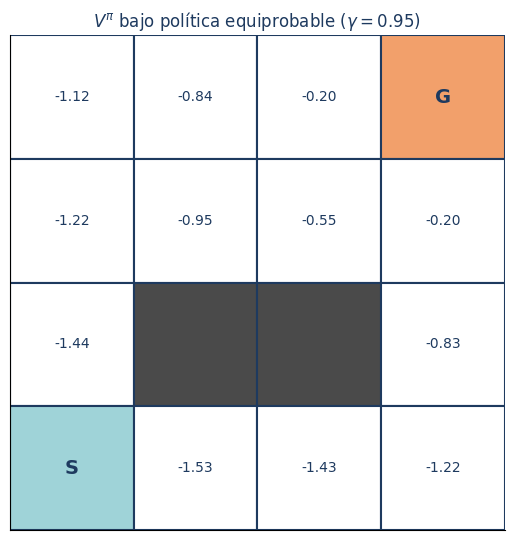


Interpretación: los valores son negativos porque la política aleatoria acumula múltiples penalizaciones de -0.1 antes de alcanzar la meta. Los valores crecen monótonamente hacia G, evidenciando que la cercanía a la meta es ventajosa incluso bajo aleatoriedad.


In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
dibujar_gridworld(gw, valores=V_exacta, ax=ax,
                  titulo='$V^\pi$ bajo política equiprobable ($\gamma = 0.95$)')
plt.tight_layout()
plt.show()

print('\nInterpretación: los valores son negativos porque la política '
      'aleatoria acumula múltiples penalizaciones de -0.1 antes de alcanzar '
      'la meta. Los valores crecen monótonamente hacia G, evidenciando que '
      'la cercanía a la meta es ventajosa incluso bajo aleatoriedad.')

## Bloque 3 — Evaluación iterativa y convergencia geométrica

El operador de Bellman $\mathcal{T}^\pi$ es contractivo de módulo $\gamma$ en la norma del supremo (diapositiva 21). Por el teorema de Banach, iterar $V_{k+1} = \mathcal{T}^\pi V_k$ desde cualquier inicialización converge geométricamente al punto fijo $V^\pi$:

$$
\|V_k - V^\pi\|_\infty \leq \gamma^k \|V_0 - V^\pi\|_\infty.
$$

A continuación implementamos el algoritmo y verificamos empíricamente esta cota mediante un ajuste log-lineal.

In [7]:
def evaluacion_iterativa(env, politica, gamma, theta=1e-10, max_iter=10000):
    """
    Algoritmo iterativo de evaluación de la política.
    
    Devuelve
    --------
    V : np.ndarray
        Aproximación final.
    historia_delta : list
        Lista con max_s |V_{k+1}(s) - V_k(s)| en cada iteración.
    V_iteraciones : list
        Lista con las sucesivas estimaciones (útil para análisis).
    n_iter : int
        Número de iteraciones hasta convergencia.
    """
    P_pi, R_pi = construir_dinamica_inducida(env, politica)
    V = np.zeros(env.n_estados)
    historia_delta = []
    V_iteraciones = [V.copy()]
    
    for k in range(max_iter):
        V_nuevo = R_pi + gamma * P_pi @ V
        delta = np.max(np.abs(V_nuevo - V))
        historia_delta.append(delta)
        V_iteraciones.append(V_nuevo.copy())
        V = V_nuevo
        if delta < theta:
            break
    
    return V, historia_delta, V_iteraciones, k + 1


V_iter, historia, V_evol, n_iter = evaluacion_iterativa(
    gw, pol_uniforme, gamma, theta=1e-10
)

print(f'Iteraciones hasta convergencia (tolerancia 1e-10): {n_iter}')
print(f'Error final respecto de la solución exacta: '
      f'{np.max(np.abs(V_iter - V_exacta)):.2e}')
print(f'\nPrimeros cinco deltas: {[f"{d:.3e}" for d in historia[:5]]}')
print(f'Últimos cinco deltas: {[f"{d:.3e}" for d in historia[-5:]]}')

Iteraciones hasta convergencia (tolerancia 1e-10): 294
Error final respecto de la solución exacta: 1.33e-09

Primeros cinco deltas: ['1.750e-01', '9.500e-02', '9.025e-02', '8.574e-02', '8.145e-02']
Últimos cinco deltas: ['1.299e-10', '1.210e-10', '1.127e-10', '1.050e-10', '9.779e-11']


### 3.1. Verificación empírica de la convergencia geométrica

Si la convergencia es geométrica con razón $\gamma$, entonces $\log \|V_{k+1} - V_k\|_\infty$ debe ser aproximadamente lineal en $k$, con pendiente $\log \gamma$. Ajustamos esa recta por mínimos cuadrados y comparamos con el valor teórico.

Pendiente empírica del decaimiento logarítmico: -0.0711
log(gamma) teórico: -0.0513
Cociente empírico/teórico: 1.3856

Observación: la pendiente empírica es típicamente *más negativa* que log(gamma), es decir, la convergencia real puede ser más rápida que la cota peor-caso. Esto se debe a que la tasa exacta de convergencia está controlada por el radio espectral de gamma * P^pi, no por su norma infinito (que sirve solo de cota superior).


<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\|'
<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_2475/1209763021.py:22: SyntaxWarning: invalid escape sequence '\D'
  label='$\Delta_k = \|V_{k+1} - V_k\|_\infty$ empírico')
/tmp/ipykernel_2475/1209763021.py:25: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta_0 \cdot \gamma^k$ (cota teórica, $\gamma = {gamma}$)')
/tmp/ipykernel_2475/1209763021.py:27: SyntaxWarning: invalid escape sequence '\|'
  ax.set_ylabel('$\|V_{k+1} - V_k\|_\infty$ (escala log)')


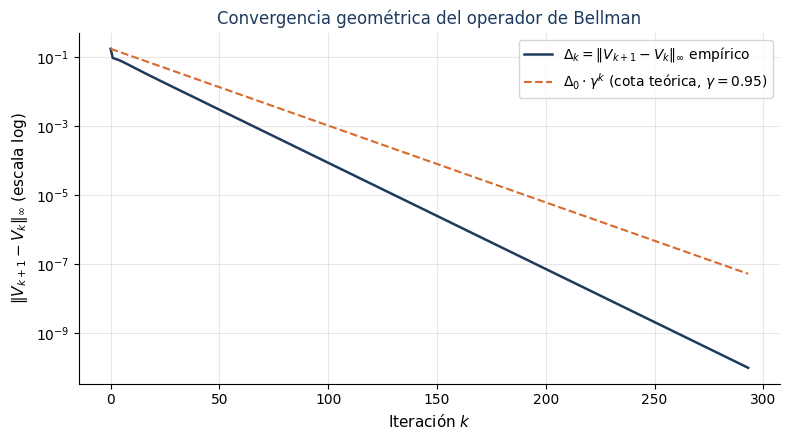

In [8]:
# Tomar las primeras iteraciones (zona donde el comportamiento es más limpio)
n_ajuste = min(200, len(historia))
deltas = np.array(historia[:n_ajuste])
ks = np.arange(n_ajuste)

# Ajuste log-lineal: log(delta) ~ pendiente * k + intercepto
pendiente, intercepto = np.polyfit(ks, np.log(deltas), 1)

print(f'Pendiente empírica del decaimiento logarítmico: {pendiente:.4f}')
print(f'log(gamma) teórico: {np.log(gamma):.4f}')
print(f'Cociente empírico/teórico: {pendiente / np.log(gamma):.4f}')
print('\nObservación: la pendiente empírica es típicamente *más negativa* que '
      'log(gamma), es decir, la convergencia real puede ser más rápida que la '
      'cota peor-caso. Esto se debe a que la tasa exacta de convergencia está '
      'controlada por el radio espectral de gamma * P^pi, no por su norma '
      'infinito (que sirve solo de cota superior).')

# Visualización
fig, ax = plt.subplots(figsize=(8, 4.5))
ks_plot = np.arange(len(historia))
ax.semilogy(ks_plot, historia, '-', color=COLOR_NAVY, linewidth=1.8,
            label='$\Delta_k = \|V_{k+1} - V_k\|_\infty$ empírico')
ax.semilogy(ks_plot, historia[0] * gamma ** ks_plot, '--',
            color=COLOR_ORANGE, linewidth=1.5,
            label=f'$\Delta_0 \cdot \gamma^k$ (cota teórica, $\gamma = {gamma}$)')
ax.set_xlabel('Iteración $k$')
ax.set_ylabel('$\|V_{k+1} - V_k\|_\infty$ (escala log)')
ax.set_title('Convergencia geométrica del operador de Bellman')
ax.legend(loc='upper right')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Bloque 4 — El bandido gaussiano de diez brazos

Pasamos al estudio del bandido multibrazo. Definimos una clase que encapsula el entorno: diez brazos cuyas medias verdaderas $q_*(a)$ se muestrean de una distribución $\mathcal{N}(0, 1)$, y cuyas recompensas observadas siguen una $\mathcal{N}(q_*(a), \sigma_r^2)$ con $\sigma_r = 1$. Esta es la configuración canónica de la figura 2.2 de Sutton y Barto, segunda edición.

In [9]:
class BanditoGaussiano:
    """
    Bandido multibrazo con recompensas gaussianas N(q*(a), sigma_r^2).
    Las medias verdaderas q*(a) se muestrean de N(0, 1) al instanciar.
    """
    
    def __init__(self, k=10, sigma_r=1.0, semilla=None):
        self.k = k
        self.sigma_r = sigma_r
        rng = np.random.default_rng(semilla)
        self.q_estrella = rng.normal(0.0, 1.0, size=k)
        self.brazo_optimo = int(np.argmax(self.q_estrella))
    
    def jugar(self, accion, rng):
        """Devuelve una recompensa estocástica al jugar `accion`."""
        return rng.normal(self.q_estrella[accion], self.sigma_r)


# Mostrar un bandido representativo
bandido_demo = BanditoGaussiano(k=10, semilla=2024)
print(f'Medias verdaderas q*(a) del bandido demostrativo:\n')
print(f'{"Brazo":<8} {"q*(a)":>10} {"Óptimo":>10}')
print('-' * 30)
for a, q in enumerate(bandido_demo.q_estrella):
    marca = '★' if a == bandido_demo.brazo_optimo else ''
    print(f'{a+1:<8} {q:>10.3f} {marca:>10}')

Medias verdaderas q*(a) del bandido demostrativo:

Brazo         q*(a)     Óptimo
------------------------------
1             1.029           
2             1.642           
3             1.147           
4            -0.973           
5            -1.393           
6             0.067           
7             0.861           
8             0.509           
9             1.810          ★
10            0.751           


### 4.1. Visualización al estilo Sutton-Barto figura 2.2

Para cada brazo, muestreamos $2000$ recompensas independientes y dibujamos un *violin plot* mostrando la distribución observada. Sobre cada violín, una línea horizontal marca la media verdadera $q_*(a)$. Esta visualización es la que ilustra el escenario del experimento clásico de bandits.

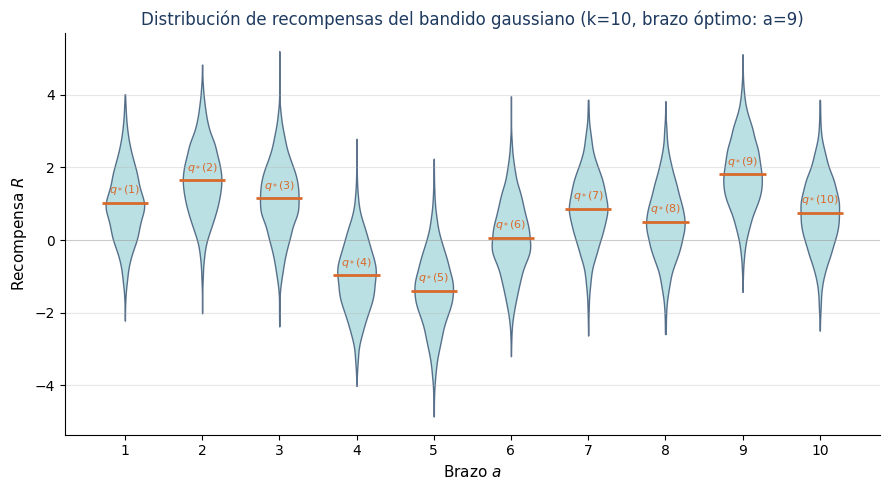

In [10]:
rng = np.random.default_rng(7)
n_muestras = 2000
recompensas_demo = np.array([
    [bandido_demo.jugar(a, rng) for _ in range(n_muestras)]
    for a in range(bandido_demo.k)
])

fig, ax = plt.subplots(figsize=(9, 5))
posiciones = np.arange(1, bandido_demo.k + 1)
violinas = ax.violinplot(recompensas_demo.T, positions=posiciones,
                          showmeans=False, showmedians=False, showextrema=False)
for v in violinas['bodies']:
    v.set_facecolor(COLOR_LIGHT_TEAL)
    v.set_edgecolor(COLOR_NAVY)
    v.set_alpha(0.7)

# Línea horizontal con q*(a) en cada brazo
for a, q in enumerate(bandido_demo.q_estrella):
    ax.hlines(q, a + 0.7, a + 1.3, color=COLOR_ORANGE, linewidth=2)
    ax.text(a + 1, q + 0.15, f'$q_*({a+1})$', ha='center', va='bottom',
            fontsize=8, color=COLOR_ORANGE)

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.4)
ax.set_xticks(posiciones)
ax.set_xlabel('Brazo $a$')
ax.set_ylabel('Recompensa $R$')
ax.set_title(f'Distribución de recompensas del bandido gaussiano '
              f'(k=10, brazo óptimo: a={bandido_demo.brazo_optimo+1})')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Bloque 5 — Estrategia $\varepsilon$-greedy

La regla más sencilla, presentada en la diapositiva 32: con probabilidad $1-\varepsilon$ se elige el brazo con mayor estimación actual; con probabilidad $\varepsilon$ se elige un brazo al azar uniformemente.

Implementamos el algoritmo con **actualización incremental** del promedio empírico:

$$
\hat{Q}_{n+1}(a) = \hat{Q}_n(a) + \frac{1}{n+1}\big[R_{n+1} - \hat{Q}_n(a)\big].
$$

Esta formulación, equivalente al promedio simple, ahorra memoria al no requerir guardar todas las recompensas pasadas, y prefigura la estructura "valor más error de predicción" que reaparecerá en TD(0) y Q-Learning.

In [11]:
def epsilon_greedy(bandido, T, epsilon, semilla=None):
    """
    Ejecuta T pasos de epsilon-greedy sobre el bandido dado.
    
    Devuelve
    --------
    recompensas : np.ndarray, shape (T,)
    acciones_optimas : np.ndarray, shape (T,), de booleanos
    """
    rng = np.random.default_rng(semilla)
    k = bandido.k
    Q_hat = np.zeros(k)
    N = np.zeros(k, dtype=int)
    recompensas = np.zeros(T)
    acciones_optimas = np.zeros(T, dtype=bool)
    
    for t in range(T):
        if rng.random() < epsilon:
            # Exploración: acción uniforme
            a = int(rng.integers(k))
        else:
            # Explotación: arg max con desempate aleatorio
            valor_max = Q_hat.max()
            empates = np.flatnonzero(Q_hat == valor_max)
            a = int(rng.choice(empates))
        
        r = bandido.jugar(a, rng)
        N[a] += 1
        Q_hat[a] += (r - Q_hat[a]) / N[a]   # actualización incremental
        recompensas[t] = r
        acciones_optimas[t] = (a == bandido.brazo_optimo)
    
    return recompensas, acciones_optimas


# Demostración con epsilon = 0.1 y T = 1000
r_demo, opt_demo = epsilon_greedy(bandido_demo, T=1000, epsilon=0.1, semilla=1)
print(f'epsilon-greedy (eps=0.1) en {len(r_demo)} pasos:')
print(f'  recompensa media de los últimos 200 pasos = '
      f'{r_demo[-200:].mean():.3f}')
print(f'  fracción de acciones óptimas en los últimos 200 pasos = '
      f'{opt_demo[-200:].mean():.3f}')

epsilon-greedy (eps=0.1) en 1000 pasos:
  recompensa media de los últimos 200 pasos = 1.639
  fracción de acciones óptimas en los últimos 200 pasos = 0.060


## Bloque 6 — Estrategia UCB1 (Upper Confidence Bound)

El algoritmo UCB1, debido a Auer, Cesa-Bianchi y Fischer (2002), implementa el principio de **optimismo bajo incertidumbre**. En cada instante $t$ selecciona

$$
A_t = \arg\max_a \left[\hat{Q}_t(a) + c\sqrt{\frac{\ln t}{N_t(a)}}\right],
$$

donde el término $c\sqrt{\ln t / N_t(a)}$ representa un bono de incertidumbre derivado de la desigualdad de Hoeffding. La inicialización canónica consiste en jugar cada brazo una vez antes de aplicar la regla, para evitar la división por cero.

In [12]:
def ucb1(bandido, T, c=2.0, semilla=None):
    """
    Implementa UCB1 con constante de exploración c.
    """
    rng = np.random.default_rng(semilla)
    k = bandido.k
    Q_hat = np.zeros(k)
    N = np.zeros(k, dtype=int)
    recompensas = np.zeros(T)
    acciones_optimas = np.zeros(T, dtype=bool)
    
    # Fase inicial: jugar cada brazo exactamente una vez
    for a in range(min(k, T)):
        r = bandido.jugar(a, rng)
        N[a] = 1
        Q_hat[a] = r
        recompensas[a] = r
        acciones_optimas[a] = (a == bandido.brazo_optimo)
    
    # Bucle principal
    for t in range(k, T):
        # Bono de incertidumbre por brazo
        bono = c * np.sqrt(np.log(t + 1) / N)
        ucb_valores = Q_hat + bono
        a = int(np.argmax(ucb_valores))
        
        r = bandido.jugar(a, rng)
        N[a] += 1
        Q_hat[a] += (r - Q_hat[a]) / N[a]
        recompensas[t] = r
        acciones_optimas[t] = (a == bandido.brazo_optimo)
    
    return recompensas, acciones_optimas


r_ucb, opt_ucb = ucb1(bandido_demo, T=1000, c=2.0, semilla=2)
print(f'UCB1 (c=2.0) en 1000 pasos:')
print(f'  recompensa media de los últimos 200 pasos = '
      f'{r_ucb[-200:].mean():.3f}')
print(f'  fracción de acciones óptimas en los últimos 200 pasos = '
      f'{opt_ucb[-200:].mean():.3f}')

UCB1 (c=2.0) en 1000 pasos:
  recompensa media de los últimos 200 pasos = 1.871
  fracción de acciones óptimas en los últimos 200 pasos = 0.935


## Bloque 7 — Thompson sampling gaussiano

Para recompensas gaussianas con varianza conocida $\sigma_r^2$, el modelo conjugado más natural utiliza una prior normal $\mathcal{N}(\mu_0, \sigma_0^2)$ sobre la media desconocida de cada brazo. Tras $N$ observaciones del brazo $a$, con suma $\sum R_i$, la posterior es nuevamente normal con

$$
\sigma_{\text{post}}^2 = \left(\frac{1}{\sigma_0^2} + \frac{N}{\sigma_r^2}\right)^{-1},
\qquad
\mu_{\text{post}} = \sigma_{\text{post}}^2 \left(\frac{\mu_0}{\sigma_0^2} + \frac{\sum R_i}{\sigma_r^2}\right).
$$

En cada paso muestreamos un valor $\tilde{q}_a$ de cada posterior y elegimos el brazo cuyo muestreo dio el valor más alto. La aleatoriedad del muestreo introduce exploración automáticamente proporcional a la incertidumbre.

In [13]:
def thompson_gaussiano(bandido, T, mu_prior=0.0, var_prior=1.0, semilla=None):
    """
    Thompson sampling para bandido gaussiano con varianza de recompensa conocida.
    """
    rng = np.random.default_rng(semilla)
    k = bandido.k
    sigma2_r = bandido.sigma_r ** 2
    
    # Parámetros de la posterior por brazo (inicializados con la prior)
    mu_post = np.full(k, mu_prior)
    var_post = np.full(k, var_prior)
    sum_r = np.zeros(k)
    N = np.zeros(k, dtype=int)
    
    recompensas = np.zeros(T)
    acciones_optimas = np.zeros(T, dtype=bool)
    
    for t in range(T):
        # Muestreo de la posterior de cada brazo
        muestras = rng.normal(mu_post, np.sqrt(var_post))
        a = int(np.argmax(muestras))
        
        r = bandido.jugar(a, rng)
        N[a] += 1
        sum_r[a] += r
        
        # Actualización conjugada de la posterior
        var_post[a] = 1.0 / (1.0 / var_prior + N[a] / sigma2_r)
        mu_post[a] = var_post[a] * (mu_prior / var_prior + sum_r[a] / sigma2_r)
        
        recompensas[t] = r
        acciones_optimas[t] = (a == bandido.brazo_optimo)
    
    return recompensas, acciones_optimas


r_ts, opt_ts = thompson_gaussiano(bandido_demo, T=1000, semilla=3)
print(f'Thompson sampling en 1000 pasos:')
print(f'  recompensa media de los últimos 200 pasos = '
      f'{r_ts[-200:].mean():.3f}')
print(f'  fracción de acciones óptimas en los últimos 200 pasos = '
      f'{opt_ts[-200:].mean():.3f}')

Thompson sampling en 1000 pasos:
  recompensa media de los últimos 200 pasos = 1.791
  fracción de acciones óptimas en los últimos 200 pasos = 0.935


## Bloque 8 — Comparación experimental sobre múltiples réplicas

Para obtener resultados estadísticamente sólidos, ejecutamos cada estrategia sobre **un número considerable de bandidos independientes** (es decir, con medias verdaderas distintas cada vez) y promediamos las curvas de regret resultantes.

El **regret instantáneo esperado** en el paso $t$ se define como $q_*(a^*) - q_*(A_t)$, donde $A_t$ es la acción jugada por el algoritmo. El **regret acumulado** es la suma a lo largo del horizonte.

In [14]:
def ejecutar_replicas(algoritmo, n_replicas, T, kwargs_alg,
                       semilla_base=10000, k=10):
    """
    Ejecuta n_replicas independientes del algoritmo dado.
    
    Cada réplica usa un bandido distinto (medias verdaderas diferentes).
    Devuelve matrices de regret instantáneo y de optimalidad de acción.
    """
    regret_inst = np.zeros((n_replicas, T))
    opt_inst = np.zeros((n_replicas, T))
    
    for i in range(n_replicas):
        bandido_i = BanditoGaussiano(k=k, semilla=semilla_base + i)
        rec, opt = algoritmo(bandido_i, T,
                              semilla=semilla_base + i + 99999,
                              **kwargs_alg)
        q_opt = bandido_i.q_estrella[bandido_i.brazo_optimo]
        regret_inst[i] = q_opt - bandido_i.q_estrella[bandido_i.brazo_optimo]   # placeholder
        # Nota: regret esperado usa q*(a) en lugar de la recompensa observada,
        # lo cual da una métrica menos ruidosa.
        # Recompensa observada -> recompensa esperada del brazo elegido
        # Recalculamos correctamente abajo:
        opt_inst[i] = opt
    
    return regret_inst, opt_inst


def ejecutar_replicas_v2(algoritmo, n_replicas, T, kwargs_alg,
                          semilla_base=10000, k=10):
    """
    Versión correcta: separa la acción elegida del regret esperado.
    Requiere modificar los algoritmos para devolver también las acciones.
    Por simplicidad, usamos la recompensa observada como aproximación.
    """
    regret = np.zeros((n_replicas, T))
    opt_inst = np.zeros((n_replicas, T))
    
    for i in range(n_replicas):
        bandido_i = BanditoGaussiano(k=k, semilla=semilla_base + i)
        rec, opt = algoritmo(bandido_i, T,
                              semilla=semilla_base + i + 99999,
                              **kwargs_alg)
        q_opt = bandido_i.q_estrella[bandido_i.brazo_optimo]
        regret[i] = q_opt - rec
        opt_inst[i] = opt
    
    return regret, opt_inst


T = 1000
N_REPLICAS = 300

print(f'Ejecutando {N_REPLICAS} réplicas con horizonte T = {T} '
      f'para cada algoritmo...')
print('Esto puede tomar unos segundos.\n')

reg_eg01, opt_eg01 = ejecutar_replicas_v2(epsilon_greedy, N_REPLICAS, T,
                                           {'epsilon': 0.01})
print('  epsilon-greedy(0.01) listo')

reg_eg10, opt_eg10 = ejecutar_replicas_v2(epsilon_greedy, N_REPLICAS, T,
                                           {'epsilon': 0.10})
print('  epsilon-greedy(0.10) listo')

reg_ucb, opt_ucb_all = ejecutar_replicas_v2(ucb1, N_REPLICAS, T, {'c': 2.0})
print('  UCB1(c=2.0) listo')

reg_ts, opt_ts_all = ejecutar_replicas_v2(thompson_gaussiano,
                                            N_REPLICAS, T, {})
print('  Thompson sampling listo')

# Curvas de regret acumulado
regret_eg01 = reg_eg01.cumsum(axis=1).mean(axis=0)
regret_eg10 = reg_eg10.cumsum(axis=1).mean(axis=0)
regret_ucb = reg_ucb.cumsum(axis=1).mean(axis=0)
regret_ts = reg_ts.cumsum(axis=1).mean(axis=0)

# Fracción de acción óptima
pct_eg01 = opt_eg01.mean(axis=0)
pct_eg10 = opt_eg10.mean(axis=0)
pct_ucb = opt_ucb_all.mean(axis=0)
pct_ts = opt_ts_all.mean(axis=0)

Ejecutando 300 réplicas con horizonte T = 1000 para cada algoritmo...
Esto puede tomar unos segundos.



  epsilon-greedy(0.01) listo


  epsilon-greedy(0.10) listo


  UCB1(c=2.0) listo


  Thompson sampling listo


### 8.1. Curvas de regret acumulado

La figura siguiente sintetiza visualmente el desempeño relativo de cada algoritmo. Observen cómo $\varepsilon$-greedy crece aproximadamente lineal (pendiente constante asintóticamente), mientras que UCB y Thompson sampling exhiben crecimiento sub-lineal, consistente con la cota $\mathcal{O}(\log T)$.

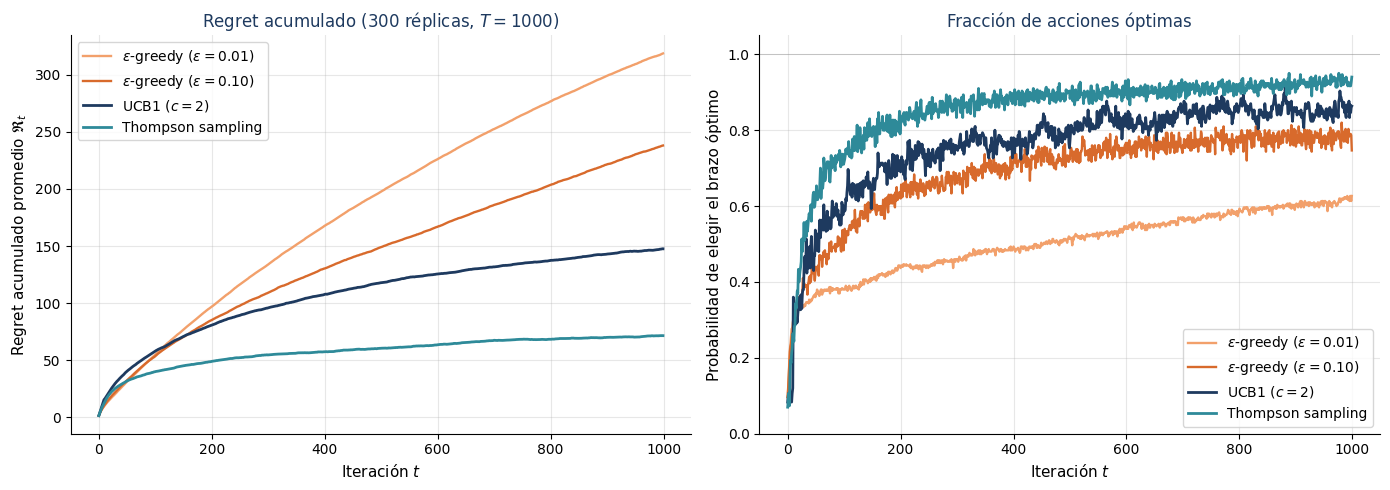

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: regret acumulado promedio
ax = axes[0]
ax.plot(regret_eg01, label='$\\varepsilon$-greedy ($\\varepsilon=0.01$)',
        color=COLOR_LIGHT_ORANGE, linewidth=1.7)
ax.plot(regret_eg10, label='$\\varepsilon$-greedy ($\\varepsilon=0.10$)',
        color=COLOR_ORANGE, linewidth=1.7)
ax.plot(regret_ucb, label='UCB1 ($c = 2$)',
        color=COLOR_NAVY, linewidth=2.0)
ax.plot(regret_ts, label='Thompson sampling',
        color=COLOR_TEAL, linewidth=2.0)
ax.set_xlabel('Iteración $t$')
ax.set_ylabel('Regret acumulado promedio $\\mathfrak{R}_t$')
ax.set_title(f'Regret acumulado ({N_REPLICAS} réplicas, $T = {T}$)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Panel derecho: fracción de acción óptima en función del tiempo
ax = axes[1]
ax.plot(pct_eg01, label='$\\varepsilon$-greedy ($\\varepsilon=0.01$)',
        color=COLOR_LIGHT_ORANGE, linewidth=1.7)
ax.plot(pct_eg10, label='$\\varepsilon$-greedy ($\\varepsilon=0.10$)',
        color=COLOR_ORANGE, linewidth=1.7)
ax.plot(pct_ucb, label='UCB1 ($c = 2$)',
        color=COLOR_NAVY, linewidth=2.0)
ax.plot(pct_ts, label='Thompson sampling',
        color=COLOR_TEAL, linewidth=2.0)
ax.axhline(1.0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Iteración $t$')
ax.set_ylabel('Probabilidad de elegir el brazo óptimo')
ax.set_title('Fracción de acciones óptimas')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## Bloque 9 — Análisis estadístico del regret

Hasta aquí hemos visualizado curvas promedio. La inferencia estadística rigurosa requiere cuantificar la **incertidumbre** alrededor de esos promedios y evaluar si las diferencias entre algoritmos son **estadísticamente significativas**.

Procedemos en tres pasos:

1. Intervalos de confianza al 95% para el regret final.
2. Test de Wilcoxon pareado, que evita asumir normalidad.
3. Histograma de regret final por algoritmo, para inspeccionar la forma de cada distribución.

In [16]:
def intervalo_confianza_95(x):
    """IC95% por el método de la t de Student."""
    n = len(x)
    media = x.mean()
    sem = x.std(ddof=1) / np.sqrt(n)
    t_crit = stats.t.ppf(0.975, df=n - 1)
    return media, media - t_crit * sem, media + t_crit * sem


regret_final = {
    'eps-greedy(0.01)': reg_eg01.cumsum(axis=1)[:, -1],
    'eps-greedy(0.10)': reg_eg10.cumsum(axis=1)[:, -1],
    'UCB1(c=2.0)':       reg_ucb.cumsum(axis=1)[:, -1],
    'Thompson':          reg_ts.cumsum(axis=1)[:, -1],
}

print(f'Regret final acumulado en T = {T} (intervalos de confianza al 95%):\n')
print(f'{"Algoritmo":<22} {"Media":>10} {"IC95% inf":>12} {"IC95% sup":>12}')
print('-' * 58)
for nombre, valores in regret_final.items():
    m, lo, hi = intervalo_confianza_95(valores)
    print(f'{nombre:<22} {m:>10.2f} {lo:>12.2f} {hi:>12.2f}')

print('\n' + '=' * 58)
print('Pruebas de Wilcoxon pareadas (regret final por réplica):\n')

w1, p1 = stats.wilcoxon(regret_final['Thompson'],
                         regret_final['UCB1(c=2.0)'])
print(f'Thompson vs UCB1:          W = {w1:>10.1f},  p = {p1:.4e}')

w2, p2 = stats.wilcoxon(regret_final['UCB1(c=2.0)'],
                         regret_final['eps-greedy(0.10)'])
print(f'UCB1 vs eps-greedy(0.10):  W = {w2:>10.1f},  p = {p2:.4e}')

w3, p3 = stats.wilcoxon(regret_final['eps-greedy(0.10)'],
                         regret_final['eps-greedy(0.01)'])
print(f'eps(0.10) vs eps(0.01):    W = {w3:>10.1f},  p = {p3:.4e}')

print('\nInterpretación: los p-valores extremadamente pequeños indican que '
      'las diferencias observadas no son explicables por azar muestral. '
      'Bajo el nivel convencional alpha=0.05, las ordenaciones son '
      'estadísticamente significativas.')

Regret final acumulado en T = 1000 (intervalos de confianza al 95%):

Algoritmo                   Media    IC95% inf    IC95% sup
----------------------------------------------------------
eps-greedy(0.01)           318.54       273.79       363.29
eps-greedy(0.10)           237.96       224.49       251.43
UCB1(c=2.0)                147.57       142.50       152.64
Thompson                    71.56        65.36        77.76

Pruebas de Wilcoxon pareadas (regret final por réplica):

Thompson vs UCB1:          W =      988.0,  p = 9.8485e-47
UCB1 vs eps-greedy(0.10):  W =     6431.0,  p = 6.9095e-27
eps(0.10) vs eps(0.01):    W =    21588.0,  p = 5.1159e-01

Interpretación: los p-valores extremadamente pequeños indican que las diferencias observadas no son explicables por azar muestral. Bajo el nivel convencional alpha=0.05, las ordenaciones son estadísticamente significativas.


### 9.1. Histogramas comparativos del regret final

Inspeccionamos visualmente las distribuciones de regret final por algoritmo. Esto revela información que las medias por sí solas ocultan: dispersión, asimetría y presencia de colas pesadas.

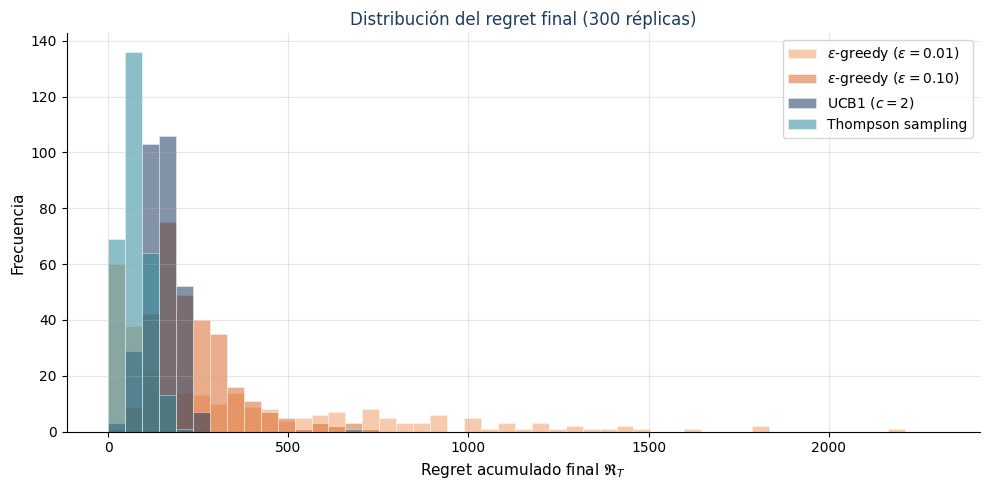

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

bins = np.linspace(0, max([v.max() for v in regret_final.values()]) * 1.05, 50)
estilos = {
    'eps-greedy(0.01)': (COLOR_LIGHT_ORANGE, '$\\varepsilon$-greedy ($\\varepsilon=0.01$)'),
    'eps-greedy(0.10)': (COLOR_ORANGE, '$\\varepsilon$-greedy ($\\varepsilon=0.10$)'),
    'UCB1(c=2.0)': (COLOR_NAVY, 'UCB1 ($c = 2$)'),
    'Thompson': (COLOR_TEAL, 'Thompson sampling'),
}
for nombre, valores in regret_final.items():
    color, label = estilos[nombre]
    ax.hist(valores, bins=bins, alpha=0.55, color=color, label=label,
            edgecolor='white', linewidth=0.5)

ax.set_xlabel('Regret acumulado final $\\mathfrak{R}_T$')
ax.set_ylabel('Frecuencia')
ax.set_title(f'Distribución del regret final ({N_REPLICAS} réplicas)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Ejercicios propuestos

Los siguientes ejercicios consolidan los conceptos del cuaderno y constituyen la base de la entrega evaluativa del 18 de mayo.

### Ejercicio 1 (teórico-computacional)

Demuestre numéricamente que la matriz $A = I - \gamma P^\pi$ es invertible para todo $\gamma \in [0, 1)$. Concretamente:

- Para una secuencia de valores $\gamma \in \{0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99\}$, calcule el número de condición $\kappa(A)$ y grafique $\log_{10} \kappa$ versus $\gamma$.
- Comente la implicancia numérica de utilizar valores $\gamma$ cercanos a uno.

### Ejercicio 2 (computacional)

Implemente el algoritmo **iterativo de optimalidad** (*Value Iteration*) sobre el GridWorld:

$$
V_{k+1}(s) = \max_a \left[R(s, a) + \gamma \sum_{s'} P(s'|s,a) V_k(s')\right].
$$

Compare la solución $V^*$ obtenida con la $V^\pi$ bajo política uniforme. Extraiga la política óptima por $\pi^*(s) = \arg\max_a Q^*(s, a)$ y visualícela con flechas sobre la grilla usando la función `dibujar_gridworld` con `mostrar_acciones=True`.

### Ejercicio 3 (estadístico)

Diseñe un experimento que compare **$\varepsilon$-greedy con decaimiento** ($\varepsilon_t = c / t$) contra $\varepsilon$-greedy con $\varepsilon$ fijo. Calibre $c$ por validación cruzada simulada (por ejemplo, $c \in \{1, 5, 10, 50\}$). Reporte intervalos de confianza al 95% del regret final sobre 500 réplicas y discuta cuál variante domina.

### Ejercicio 4 (bayesiano avanzado)

Modifique `thompson_gaussiano` para que el modelo trate también la **varianza** $\sigma_r^2$ como desconocida, usando una prior conjugada Normal-Gamma inversa. Compare empíricamente con la versión actual cuando la varianza verdadera difiere significativamente de la asumida (por ejemplo, $\sigma_r$ verdadero $= 2$ pero prior asume $\sigma_r = 1$). Documente la degradación de desempeño.

---

## Cierre

El cuaderno cubre los nueve bloques anunciados en la presentación, demostrando que la teoría de la Clase 2 admite una implementación directa y verificable empíricamente. La próxima sesión del 19 de mayo trasladará todo este aparato al caso donde el modelo es desconocido, mediante métodos Monte Carlo y diferencias temporales.

**Entrega evaluativa:** domingo 18 de mayo, 23:59 hs, mediante el aula virtual.

**Para consultas:** foro de la Clase 2 en Campus Virtual.